# 🫁 Lung Cancer Detection — Exploratory Data Analysis (EDA)

## Purpose
Before building any model, we need to deeply understand our dataset.  
This notebook answers the following questions:

1. Is the dataset complete and free of corrupted files?
2. Are the classes balanced (equal number of images per class)?
3. What do the images actually look like across each class?
4. Are all images the same size, or do they vary?
5. What does the pixel intensity (brightness) distribution look like per class?

## Dataset
- **Source:** `data/lung_image_sets/`
- **Classes:** `lung_aca` (Adenocarcinoma), `lung_n` (Normal), `lung_scc` (Squamous Cell Carcinoma)
- **Total images:** 15,000 (5,000 per class)

## Output
All plots are saved to the `results/` folder for use in the final report.

## Step 1 — Imports and Setup
We import all the libraries we need upfront.

- `os` — for navigating folders and file paths
- `numpy` — for numerical operations on pixel arrays
- `matplotlib` — for plotting charts and image grids
- `PIL (Pillow)` — for loading and inspecting images
- `random` — for sampling images without loading the full dataset
- `collections.Counter` — for counting occurrences (e.g. image formats)

In [2]:
import os

# Required on Windows with Anaconda to find CUDA/cuDNN DLL files for GPU support
os.add_dll_directory(r"C:\Users\ahmed\anaconda3\envs\lung_cancer\Library\bin")

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from collections import Counter
import warnings

# Suppress non-critical warnings to keep notebook output clean
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## Step 2 — Project Configuration

We define all paths and settings in one place.  
This is a best practice: if anything changes (e.g. the data folder moves),
we only need to update it here — not hunt through the whole notebook.

In [3]:
# Path to the dataset root, relative to this notebook's location (notebooks/)
# '..' means "go one folder up", so this resolves to: lung-cancer-detection/data/lung_image_sets
DATA_ROOT = r"../data/lung_image_sets"

# The three subfolder names inside lung_image_sets
CLASSES = ["lung_aca", "lung_n", "lung_scc"]

# Human-readable names used in plot labels and summaries
CLASS_NAMES = ["Lung Adenocarcinoma", "Normal", "Squamous Cell Carcinoma"]

# How many sample images to show per class in the visual grid
SAMPLES_PER_CLASS = 5

# Fixed random seed so results are reproducible every time the notebook runs
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Confirm the path resolves correctly on this machine
print(f"Dataset root  : {os.path.abspath(DATA_ROOT)}")
print(f"Classes       : {CLASSES}")
print(f"Random seed   : {RANDOM_SEED}")

Dataset root  : c:\Users\ahmed\ahmed\Desktop\lung-cancer-detection\data\lung_image_sets
Classes       : ['lung_aca', 'lung_n', 'lung_scc']
Random seed   : 42


## Step 3 — Load All Image Paths

We collect the file path of every image in the dataset and store them
in a dictionary, grouped by class.

We do **not** load the images into memory yet — 15,000 images would be
very slow and memory-heavy. We only store the paths, and open images
one at a time when needed.

In [ ]:
def get_image_paths(root, classes):
    """
    Scans each class folder and returns all valid image file paths.

    Args:
        root    (str): Path to the dataset root folder.
        classes (list): List of class subfolder names.

    Returns:
        dict: {class_name: [list of full image file paths]}
    """
    paths = {}
    for cls in classes:
        folder = os.path.join(root, cls)
        files = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            # Only include known image formats — skip any hidden or system files
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tiff"))
        ]
        paths[cls] = files
    return paths


image_paths = get_image_paths(DATA_ROOT, CLASSES)

print("Image counts per class:")
for cls, paths in image_paths.items():
    print(f"  {cls}: {len(paths)} images")

Image counts per class:
  lung_aca: 5000 images
  lung_n: 5000 images
  lung_scc: 5000 images


## Step 4 — Corruption Check

Even well-prepared datasets can contain corrupted image files —
files that appear valid but cannot actually be opened or decoded.

We use `PIL`'s `.verify()` method, which checks the file's integrity
without fully loading its pixel data into memory. This makes it fast
enough to run on all 15,000 images.

If any corrupted files are found, we print their paths so they can be
manually inspected or removed before training.

In [5]:
corrupted = []  # We'll collect any broken file paths here

for cls, paths in image_paths.items():
    valid_count = 0
    for p in paths:
        try:
            img = Image.open(p)
            img.verify()   # Checks file integrity — does NOT fully decode the image
            valid_count += 1
        except Exception:
            # If verify() raises any error, the file is corrupted
            corrupted.append(p)

    print(f"  {cls}: {valid_count} valid images")

print()
if corrupted:
    print(f"⚠️  {len(corrupted)} corrupted file(s) found:")
    for c in corrupted:
        print(f"     {c}")
else:
    print("✅ No corrupted files found. Dataset is clean.")

  lung_aca: 5000 valid images
  lung_n: 5000 valid images
  lung_scc: 5000 valid images

✅ No corrupted files found. Dataset is clean.


## Step 5 — Class Distribution

A balanced dataset means each class has roughly the same number of images.
This is critical because if one class has far more images than another,
the model will be **biased** — it will learn to predict the majority class
more often simply because it appears more during training.

We expect 5,000 images per class (perfectly balanced), but we always
verify visually with a bar chart rather than assuming.

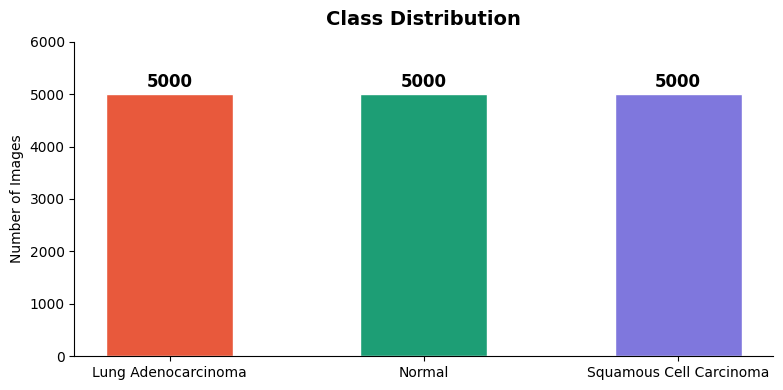

💾 Saved → results/eda_class_distribution.png


In [6]:
# Count images per class from our path dictionary
counts = {cls: len(paths) for cls, paths in image_paths.items()}

# One color per class — used consistently across all EDA plots
CLASS_COLORS = ["#E8593C", "#1D9E75", "#7F77DD"]

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    CLASS_NAMES,
    list(counts.values()),
    color=CLASS_COLORS,
    width=0.5,
    edgecolor="white"
)

# Add count labels directly above each bar for easy reading
for bar, val in zip(bars, counts.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # center of bar (x)
        bar.get_height() + 60,                # slightly above the bar top (y)
        str(val),
        ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )

ax.set_title("Class Distribution", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Number of Images")
ax.set_ylim(0, max(counts.values()) * 1.2)   # extra headroom above bars
ax.spines[["top", "right"]].set_visible(False)  # cleaner look

plt.tight_layout()
plt.savefig("../results/eda_class_distribution.png", dpi=150)
plt.show()
print("💾 Saved → results/eda_class_distribution.png")

## Step 6 — Sample Images per Class

Looking at actual images is the most important EDA step for any
computer vision project. It helps us understand:

- What visual features distinguish each class?
- Are the images consistent in appearance?
- Is the image quality acceptable?
- Are there any obvious labeling errors?

We display a random grid of 5 images per class.

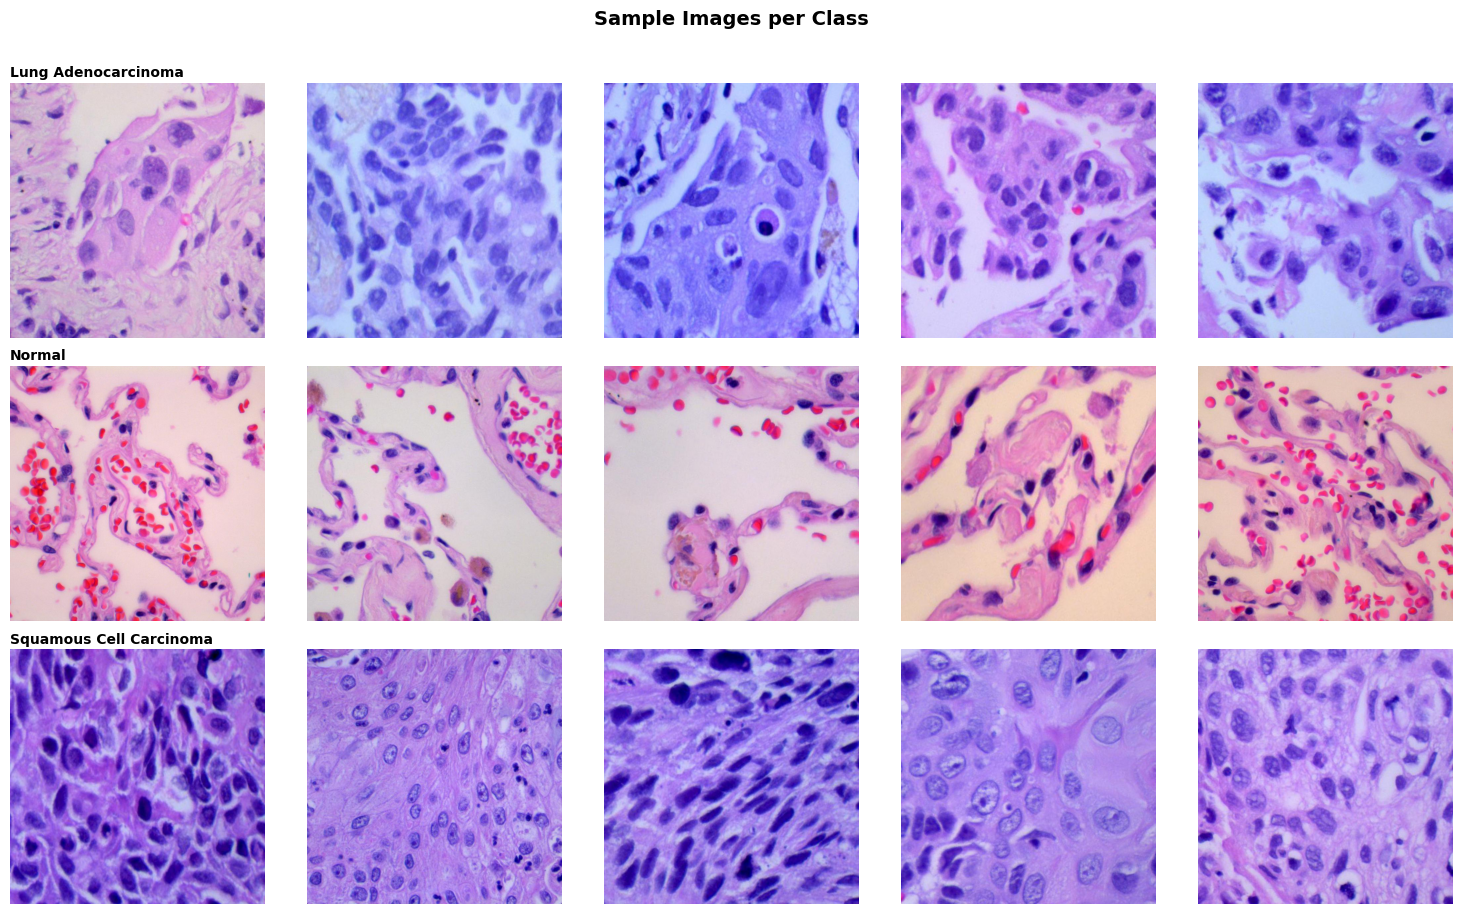

💾 Saved → results/eda_sample_images.png


In [7]:
fig, axes = plt.subplots(
    len(CLASSES), SAMPLES_PER_CLASS,
    figsize=(SAMPLES_PER_CLASS * 3, len(CLASSES) * 3)
)

for row, (cls, full_name) in enumerate(zip(CLASSES, CLASS_NAMES)):
    # Randomly pick SAMPLES_PER_CLASS images from this class
    samples = random.sample(image_paths[cls], SAMPLES_PER_CLASS)

    for col, path in enumerate(samples):
        img = Image.open(path).convert("RGB")  # ensure 3-channel RGB (no alpha/grayscale surprises)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")             # hide axis ticks — cleaner for image grids

        # Only label the first column in each row to avoid clutter
        if col == 0:
            axes[row, col].set_title(
                full_name, fontsize=10, fontweight="bold", loc="left", pad=4
            )

plt.suptitle("Sample Images per Class", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../results/eda_sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → results/eda_sample_images.png")

## Step 7 — Image Size Analysis

Neural networks require a **fixed input size**. If our images vary in size,
we need to resize them all to the same dimensions during preprocessing (Phase 2).

This step tells us:
- Are all images already the same size?
- What is the size range, so we can pick a good resize target?

We sample 200 images per class (600 total) rather than checking all 15,000.
This is statistically representative and runs in seconds instead of minutes.

Width  — min: 768px   max: 768px   mean: 768px
Height — min: 768px   max: 768px   mean: 768px
Image formats found: {'JPEG': 600}


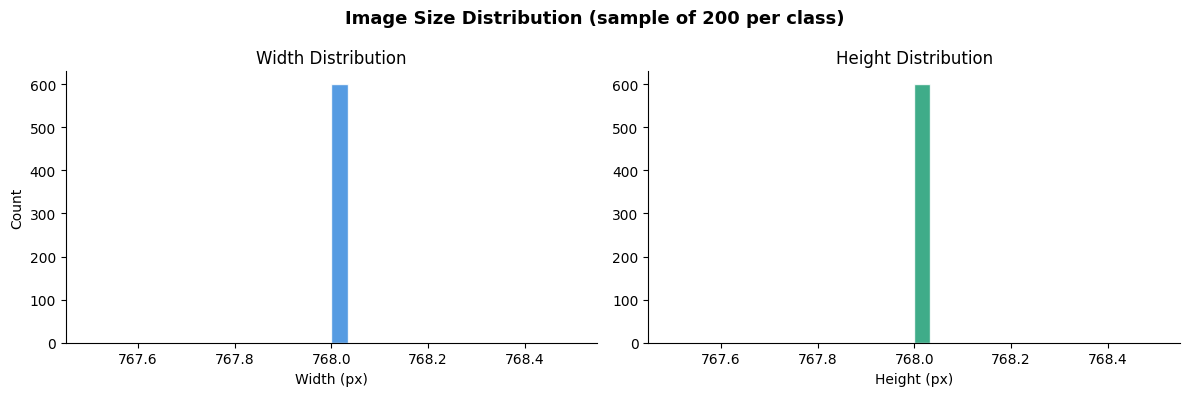

💾 Saved → results/eda_size_distribution.png


In [8]:
# How many images to sample per class for size analysis
SIZE_SAMPLE = 200

widths  = []
heights = []
formats = []

for cls, paths in image_paths.items():
    # Randomly sample to avoid checking every single image (slow)
    sampled = random.sample(paths, min(SIZE_SAMPLE, len(paths)))

    for p in sampled:
        with Image.open(p) as img:
            w, h = img.size           # PIL returns (width, height)
            widths.append(w)
            heights.append(h)
            formats.append(img.format)  # e.g. "JPEG", "PNG"

# Print size statistics
print(f"Width  — min: {min(widths)}px   max: {max(widths)}px   mean: {np.mean(widths):.0f}px")
print(f"Height — min: {min(heights)}px   max: {max(heights)}px   mean: {np.mean(heights):.0f}px")
print(f"Image formats found: {dict(Counter(formats))}")

# Plot width and height distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(widths,  bins=30, color="#378ADD", edgecolor="white", alpha=0.85)
axes[0].set_title("Width Distribution",  fontsize=12)
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].hist(heights, bins=30, color="#1D9E75", edgecolor="white", alpha=0.85)
axes[1].set_title("Height Distribution", fontsize=12)
axes[1].set_xlabel("Height (px)")
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Image Size Distribution (sample of 200 per class)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/eda_size_distribution.png", dpi=150)
plt.show()
print("💾 Saved → results/eda_size_distribution.png")

## Step 8 — Pixel Intensity Distribution

Pixel values range from 0 (black) to 255 (white).
This analysis tells us:

- Are the images bright, dark, or evenly distributed?
- Is there a significant difference in brightness between classes?
  (If yes, the model might learn brightness as a shortcut instead of real features)
- Are the images already "normalized", or do we need to scale them?

We sample 50 images per class, resize to 128×128 for speed,
then plot the pixel value distribution as an overlapping histogram.

`density=True` scales the y-axis to probability density instead of
raw counts — this makes the three classes fairly comparable on the same chart
even though they all have the same number of samples.

  lung_aca: mean pixel = 172.77   std = 57.65
  lung_n: mean pixel = 184.12   std = 43.33
  lung_scc: mean pixel = 166.34   std = 54.32


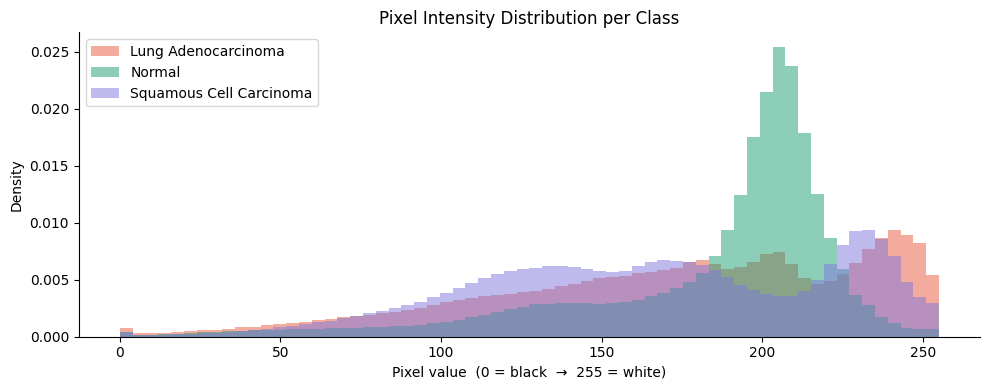

💾 Saved → results/eda_pixel_intensity.png


In [9]:
# Number of images to sample per class for intensity analysis
INTENSITY_SAMPLE = 50

fig, ax = plt.subplots(figsize=(10, 4))

for cls, full_name, color in zip(CLASSES, CLASS_NAMES, CLASS_COLORS):
    sampled = random.sample(image_paths[cls], INTENSITY_SAMPLE)
    pixel_values = []

    for p in sampled:
        img = (
            Image.open(p)
            .convert("RGB")        # ensure 3 channels
            .resize((128, 128))    # resize for speed — we only need the distribution, not full resolution
        )
        # Flatten the (128, 128, 3) array into a 1D list of all pixel values
        pixel_values.extend(np.array(img).flatten().tolist())

    ax.hist(
        pixel_values,
        bins=64,           # 64 bins gives a smooth enough curve
        alpha=0.5,         # transparency so overlapping classes are visible
        color=color,
        label=full_name,
        density=True       # normalize so all classes are on the same scale
    )

    print(f"  {cls}: mean pixel = {np.mean(pixel_values):.2f}   std = {np.std(pixel_values):.2f}")

ax.set_title("Pixel Intensity Distribution per Class", fontsize=12)
ax.set_xlabel("Pixel value  (0 = black  →  255 = white)")
ax.set_ylabel("Density")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/eda_pixel_intensity.png", dpi=150)
plt.show()
print("💾 Saved → results/eda_pixel_intensity.png")

## EDA Summary & Key Findings

This cell prints a consolidated summary of everything we discovered.
Copy this output into the final project report.

In [10]:
total = sum(counts.values())

print("=" * 55)
print("         EDA SUMMARY — LUNG CANCER DETECTION")
print("=" * 55)

print("\n📁 Dataset")
print(f"  Total images        : {total:,}")
for cls, full_name, n in zip(CLASSES, CLASS_NAMES, counts.values()):
    print(f"  {full_name:30s}: {n}  ({n/total*100:.1f}%)")

print("\n📐 Image Dimensions (sample of 200 per class)")
print(f"  Width  range        : {min(widths)} – {max(widths)} px")
print(f"  Height range        : {min(heights)} – {max(heights)} px")
print(f"  Mean size           : {np.mean(widths):.0f} × {np.mean(heights):.0f} px")

print("\n🖼️  Image Format")
print(f"  Formats detected    : {dict(Counter(formats))}")

print("\n⚠️  Data Quality")
print(f"  Corrupted files     : {len(corrupted)}")

print("\n📊 Pixel Intensity (mean across 50 sampled images per class)")
print("  (See plot above for full distribution)")

print("\n✅ Next Step → Phase 2: Data Preprocessing & Augmentation")
print("=" * 55)

         EDA SUMMARY — LUNG CANCER DETECTION

📁 Dataset
  Total images        : 15,000
  Lung Adenocarcinoma           : 5000  (33.3%)
  Normal                        : 5000  (33.3%)
  Squamous Cell Carcinoma       : 5000  (33.3%)

📐 Image Dimensions (sample of 200 per class)
  Width  range        : 768 – 768 px
  Height range        : 768 – 768 px
  Mean size           : 768 × 768 px

🖼️  Image Format
  Formats detected    : {'JPEG': 600}

⚠️  Data Quality
  Corrupted files     : 0

📊 Pixel Intensity (mean across 50 sampled images per class)
  (See plot above for full distribution)

✅ Next Step → Phase 2: Data Preprocessing & Augmentation


## What Comes Next — Phase 2: Preprocessing

Based on this EDA, in Phase 2 we will:

1. **Resize** all images to a fixed target size (determined by the size analysis above)
2. **Normalize** pixel values from [0, 255] → [0, 1] so the model trains more stably
3. **Split** the dataset into train / validation / test sets
4. **Apply augmentation** (flips, rotations, zoom) to artificially increase training variety
   and reduce overfitting